# 1. Package architecture

| Package | Role |
|---|---|
| `langchain` | streamlined high-level APIs |
| `langchain-core` | core abstractions and LCEL |
| `langchain-community` | community integrations |
| provider packages | OpenAI/Anthropic/Google/AWS/etc. integrations |
| `langgraph` | graph runtime/orchestration |
| `deepagents` | long-running agent harness |
| `langsmith` | tracing/evals/testing/deployment tooling |

**v1 change:** main `langchain` namespace was deliberately reduced. This made it look agent-centric, but retrieval/data components remain active across `langchain-core` and integration packages.

# 2. Installation

```bash
%pip install -U langchain langchain-core langchain-community 
%pip install -U langgraph  
%pip install -U deepagents
```
Typical provider installs:

```bash
pip install -U langchain-openai
pip install -U langchain-anthropic
pip install -U langchain-google-genai
pip install -U langchain-aws
pip install -U langchain-huggingface
pip install -U langchain-ollama
pip install -U langchain-mcp-adapters
pip install -U langchain-text-splitters
```

In [3]:
CHAT_MODEL = "openai:gpt-5.4-mini"
EMBED_MODEL = "openai:text-embedding-3-small"

# 3. `Document` — retrieval data unit

In [47]:
from langchain_core.documents import Document

doc = Document(
    id="doc-001",
    page_content="LangChain provides composable building blocks.",
    metadata={"source": "course_notes", "chapter": 1},
)

In [48]:
doc

Document(id='doc-001', metadata={'source': 'course_notes', 'chapter': 1}, page_content='LangChain provides composable building blocks.')

In [49]:
print(doc.page_content)
print(doc.metadata)
print(doc.id)

LangChain provides composable building blocks.
{'source': 'course_notes', 'chapter': 1}
doc-001


# 4. Chat Models

In [4]:
from langchain.chat_models import init_chat_model

In [5]:
CHAT_MODEL

'openai:gpt-5.4-mini'

In [6]:
model = init_chat_model(CHAT_MODEL)

In [7]:
type(model)

langchain_openai.chat_models.base.ChatOpenAI

In [9]:
response = model.invoke("Explain semantic search in two sentences.")

In [55]:
print(type(response), response.content)

<class 'langchain_core.messages.ai.AIMessage'> Semantic search is a way of finding information based on the meaning and intent of a query, rather than just matching exact keywords. It uses techniques like embeddings and vector similarity to return results that are conceptually related, even if they use different words.


In [56]:
responses = model.batch(["Define embeddings.","Define vector store.","Define retriever.","Define RAG."])

In [57]:
responses

[AIMessage(content='**Embeddings** are a way to represent items—like words, sentences, images, or users—as **vectors of numbers** in a continuous space.\n\nThe goal is that **similar things have similar vectors**. For example:\n- “cat” and “dog” would be placed close together\n- “cat” and “airplane” would be farther apart\n\n### Why embeddings are useful\nThey let computers work with meaning and similarity in a mathematical way. They’re used in:\n- natural language processing\n- search and recommendation systems\n- image recognition\n- clustering and classification\n\n### Example\nA word embedding might represent:\n- `"king"` → `[0.2, 0.8, -0.1, ...]`\n- `"queen"` → `[0.19, 0.82, -0.12, ...]`\n\nThese vectors aren’t usually meaningful individually, but **their position relative to each other** captures relationships.\n\n### In simple terms\nAn embedding is like a **coordinate location** for an object in a high-dimensional map where nearby points mean “more similar” or “more related.”\n

In [58]:
for r in responses:
    print(r.content)

**Embeddings** are a way to represent items—like words, sentences, images, or users—as **vectors of numbers** in a continuous space.

The goal is that **similar things have similar vectors**. For example:
- “cat” and “dog” would be placed close together
- “cat” and “airplane” would be farther apart

### Why embeddings are useful
They let computers work with meaning and similarity in a mathematical way. They’re used in:
- natural language processing
- search and recommendation systems
- image recognition
- clustering and classification

### Example
A word embedding might represent:
- `"king"` → `[0.2, 0.8, -0.1, ...]`
- `"queen"` → `[0.19, 0.82, -0.12, ...]`

These vectors aren’t usually meaningful individually, but **their position relative to each other** captures relationships.

### In simple terms
An embedding is like a **coordinate location** for an object in a high-dimensional map where nearby points mean “more similar” or “more related.”

If you want, I can also explain:
1. embed

In [60]:
for chunk in model.stream("Explain RAG in detail."):
    print(chunk.content, end="")

RAG stands for **Retrieval-Augmented Generation**. It’s a way to make a language model answer questions using **external knowledge** instead of relying only on what it memorized during training.

In simple terms:

1. **Retrieve** relevant information from a knowledge source
2. **Augment** the model’s input with that information
3. **Generate** the final answer using both the retrieved context and the model’s reasoning

---

## Why RAG exists

Large language models are good at:
- understanding language
- summarizing
- reasoning over provided text

But they have limits:
- they can be **out of date**
- they may **hallucinate** facts
- they don’t know your private documents unless you give them access
- retraining the model every time new information arrives is expensive

RAG solves this by letting the model **look things up** before answering.

---

## Core idea

Instead of asking:

> “What does the model already know?”

RAG asks:

> “What relevant information can I fetch first, then use 

```
invoke() → Use when you have one input and want one complete output; best for normal single-user requests like “summarize this text.”
batch() → Use when you have many independent inputs and want to process them together efficiently; best for cases like “summarize 100 documents/questions.”
stream() → Use when you want to receive the response progressively as it is generated instead of waiting for the full answer; best for chat UIs where users should see tokens/results immediately.
```

In [7]:
getattr(model, "profile", None)

{'name': 'GPT-5.4 mini',
 'release_date': '2026-03-17',
 'last_updated': '2026-03-17',
 'open_weights': False,
 'max_input_tokens': 400000,
 'max_output_tokens': 128000,
 'text_inputs': True,
 'image_inputs': True,
 'audio_inputs': False,
 'video_inputs': False,
 'text_outputs': True,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True,
 'structured_output': True,
 'attachment': True,
 'temperature': False,
 'image_url_inputs': True,
 'pdf_inputs': True,
 'pdf_tool_message': True,
 'image_tool_message': True,
 'tool_choice': True,
 'tool_call_streaming': True,
 'reasoning_effort_levels': ['none', 'low', 'medium', 'high', 'xhigh']}

# 5. Messages

In [8]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
messages = [
    SystemMessage(content="You are a concise teacher."),
    HumanMessage(content="What is a vector store?"),
]
messages

[SystemMessage(content='You are a concise teacher.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What is a vector store?', additional_kwargs={}, response_metadata={})]

In [9]:
msg = HumanMessage(content_blocks=[
    {"type": "text", "text": "Describe this image."},
    {"type": "image", "url": "https://example.com/image.jpg"},
])
msg.content_blocks

[{'type': 'text', 'text': 'Describe this image.'},
 {'type': 'image', 'url': 'https://example.com/image.jpg'}]

In [61]:
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    trim_messages
)

# Full chat history
history = [
    HumanMessage(content="Hello"),
    AIMessage(content="Hi! How can I help you?"),

    HumanMessage(content="What is LangChain?"),
    AIMessage(content="LangChain is a framework for building LLM applications."),

    HumanMessage(content="What is RAG?"),
    AIMessage(content="RAG combines retrieval with generation."),

    HumanMessage(content="Teach me RAG with an example.")
]


In [65]:
# Keep only the recent part of the conversation
trimmed_history = trim_messages(
    history,
    max_tokens=5,
    strategy="last",

    # For this simple demo, count each message as 1 unit
    token_counter=len,
)


In [66]:
print("FULL HISTORY")
print("-" * 50)

for message in history:
    print(type(message).__name__, ":", message.content)

FULL HISTORY
--------------------------------------------------
HumanMessage : Hello
AIMessage : Hi! How can I help you?
HumanMessage : What is LangChain?
AIMessage : LangChain is a framework for building LLM applications.
HumanMessage : What is RAG?
AIMessage : RAG combines retrieval with generation.
HumanMessage : Teach me RAG with an example.


In [67]:
print("\nTRIMMED HISTORY")
print("-" * 50)

for message in trimmed_history:
    print(type(message).__name__, ":", message.content)


TRIMMED HISTORY
--------------------------------------------------
HumanMessage : What is LangChain?
AIMessage : LangChain is a framework for building LLM applications.
HumanMessage : What is RAG?
AIMessage : RAG combines retrieval with generation.
HumanMessage : Teach me RAG with an example.


# 6. Prompt Templates

In [68]:
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate, MessagesPlaceholder

In [69]:
prompt = PromptTemplate.from_template("Explain {topic} to a {level} learner.")

In [70]:
print(prompt.format(topic="embeddings", level="beginner"))

Explain embeddings to a beginner learner.


In [77]:
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an AI teacher. Explain at {level} level."),
    ("human", "{question}"),
])

In [72]:
chat_prompt.invoke({"level":"advanced", "question":"What is LCEL?"})

ChatPromptValue(messages=[SystemMessage(content='You are an AI teacher. Explain at advanced level.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What is LCEL?', additional_kwargs={}, response_metadata={})])

In [74]:
history_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a tutor."),
    MessagesPlaceholder("history"),
    ("human", "{question}"),
])

In [76]:
history_prompt.invoke({
    "history": [HumanMessage(content="I am learning LangChain."), AIMessage(content="Great.")],
    "question": "Teach retrievers.",
})

ChatPromptValue(messages=[SystemMessage(content='You are a tutor.', additional_kwargs={}, response_metadata={}), HumanMessage(content='I am learning LangChain.', additional_kwargs={}, response_metadata={}), AIMessage(content='Great.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Teach retrievers.', additional_kwargs={}, response_metadata={})])

ChatPromptValue(messages=[SystemMessage(content='You are a tutor.', additional_kwargs={}, response_metadata={}), HumanMessage(content='I am learning LangChain.', additional_kwargs={}, response_metadata={}), AIMessage(content='Great.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Teach retrievers.', additional_kwargs={}, response_metadata={})])

In [78]:
chat_prompt

ChatPromptTemplate(input_variables=['level', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['level'], input_types={}, partial_variables={}, template='You are an AI teacher. Explain at {level} level.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='{question}'), additional_kwargs={})])

In [81]:
partial_prompt = chat_prompt.partial(level="expert")

In [82]:
partial_prompt

ChatPromptTemplate(input_variables=['question'], input_types={}, partial_variables={'level': 'expert'}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['level'], input_types={}, partial_variables={}, template='You are an AI teacher. Explain at {level} level.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='{question}'), additional_kwargs={})])

In [84]:
full_prompt = partial_prompt.invoke({"question":"Explain MMR."})

In [85]:
full_prompt

ChatPromptValue(messages=[SystemMessage(content='You are an AI teacher. Explain at expert level.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Explain MMR.', additional_kwargs={}, response_metadata={})])

partial() is used to pre-fill some prompt variables in advance, so you don’t need to pass them every time you invoke the prompt.

```
PromptTemplate
    ↓
Plain text prompt


ChatPromptTemplate
    ↓
System + Human + AI messages


MessagesPlaceholder
    ↓
Insert existing message/history
inside ChatPromptTemplate
```

# 7. Output Parsers vs Native Structured Output

In [86]:
from langchain_core.output_parsers import StrOutputParser

In [87]:
string_parser = StrOutputParser()

In [88]:
response = model.invoke("What is RAG?")

In [89]:
response

AIMessage(content='RAG usually means **Retrieval-Augmented Generation**.\n\nIt’s an approach for AI systems where a model:\n1. **Retrieves** relevant information from an external source, like documents, a database, or the web\n2. **Augments** the prompt with that information\n3. **Generates** an answer using both the retrieved content and its own language abilities\n\n### Why it’s used\nRAG helps AI:\n- answer with **more current** information\n- rely on **specific documents** instead of only model memory\n- reduce **hallucinations**\n- provide answers grounded in your data\n\n### Simple example\nIf you ask:\n> “What is our company’s leave policy?”\n\nA RAG system might:\n- search the employee handbook\n- pull the relevant section\n- then generate a response based on that text\n\n### In one sentence\nRAG = **search for relevant info first, then let the model answer using that info**.\n\nIf you want, I can also explain:\n- how RAG works step by step\n- how it differs from fine-tuning\n-

In [91]:
response.content

'RAG usually means **Retrieval-Augmented Generation**.\n\nIt’s an approach for AI systems where a model:\n1. **Retrieves** relevant information from an external source, like documents, a database, or the web\n2. **Augments** the prompt with that information\n3. **Generates** an answer using both the retrieved content and its own language abilities\n\n### Why it’s used\nRAG helps AI:\n- answer with **more current** information\n- rely on **specific documents** instead of only model memory\n- reduce **hallucinations**\n- provide answers grounded in your data\n\n### Simple example\nIf you ask:\n> “What is our company’s leave policy?”\n\nA RAG system might:\n- search the employee handbook\n- pull the relevant section\n- then generate a response based on that text\n\n### In one sentence\nRAG = **search for relevant info first, then let the model answer using that info**.\n\nIf you want, I can also explain:\n- how RAG works step by step\n- how it differs from fine-tuning\n- a diagram or code

In [90]:
string_parser.invoke(response)

'RAG usually means **Retrieval-Augmented Generation**.\n\nIt’s an approach for AI systems where a model:\n1. **Retrieves** relevant information from an external source, like documents, a database, or the web\n2. **Augments** the prompt with that information\n3. **Generates** an answer using both the retrieved content and its own language abilities\n\n### Why it’s used\nRAG helps AI:\n- answer with **more current** information\n- rely on **specific documents** instead of only model memory\n- reduce **hallucinations**\n- provide answers grounded in your data\n\n### Simple example\nIf you ask:\n> “What is our company’s leave policy?”\n\nA RAG system might:\n- search the employee handbook\n- pull the relevant section\n- then generate a response based on that text\n\n### In one sentence\nRAG = **search for relevant info first, then let the model answer using that info**.\n\nIf you want, I can also explain:\n- how RAG works step by step\n- how it differs from fine-tuning\n- a diagram or code

In [92]:
chain = model | StrOutputParser()

result = chain.invoke("What is RAG?")

print(result)

RAG usually means **Retrieval-Augmented Generation**.

It’s an AI approach where a model:

1. **Retrieves** relevant information from an external source  
   - like documents, a database, or a search index  
2. **Augments** the model’s prompt with that information  
3. **Generates** an answer using both the retrieved context and its own language ability

### Why it’s useful
- Helps answers stay **more accurate**
- Lets the AI use **up-to-date or private data**
- Reduces hallucinations by grounding responses in source material

### Simple example
If you ask: “What is our company’s refund policy?”  
A RAG system might:
- search your policy documents
- find the relevant section
- give that text to the model
- generate a clear answer based on it

If you want, I can also explain:
- how RAG works step by step,
- how it differs from fine-tuning,
- or how to build a basic RAG system.


In [ ]:
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate

In [93]:
json_parser = JsonOutputParser()

In [94]:
prompt = ChatPromptTemplate.from_messages([
    (
        "system", """Return the answer only as JSON.
        {format_instructions}
        """
    ),
    (
        "human","Extract name and skills from: {text}"
    )
])


In [95]:
json_parser.get_format_instructions()

'Return a JSON object.'

In [96]:
prompt = prompt.partial(format_instructions=json_parser.get_format_instructions())

In [97]:
prompt


ChatPromptTemplate(input_variables=['text'], input_types={}, partial_variables={'format_instructions': 'Return a JSON object.'}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['format_instructions'], input_types={}, partial_variables={}, template='Return the answer only as JSON.\n        {format_instructions}\n        '), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='Extract name and skills from: {text}'), additional_kwargs={})])

ChatPromptTemplate(input_variables=['text'], input_types={}, partial_variables={'format_instructions': 'Return a JSON object.'}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['format_instructions'], input_types={}, partial_variables={}, template='Return the answer only as JSON.\n        {format_instructions}\n        '), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='Extract name and skills from: {text}'), additional_kwargs={})])

In [98]:
chain = prompt | model | json_parser

In [99]:
result = chain.invoke({"text": "Sunny knows Python, LangChain and RAG"})

In [100]:

print(result)

{'name': 'Sunny', 'skills': ['Python', 'LangChain', 'RAG']}


In [101]:
print(type(result))

<class 'dict'>


In [102]:
from pydantic import BaseModel, Field

In [103]:
class Person(BaseModel):
    name: str = Field(description="Name of the person")
    age: int = Field(description="Age of the person")
    skills: list[str] = Field(
        description="Technical skills of the person"
    )

In [104]:
from langchain_core.output_parsers import PydanticOutputParser

In [105]:
parser = PydanticOutputParser(pydantic_object=Person)

In [106]:
parser

PydanticOutputParser(pydantic_object=<class '__main__.Person'>)

In [107]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"name": {"description": "Name of the person", "title": "Name", "type": "string"}, "age": {"description": "Age of the person", "title": "Age", "type": "integer"}, "skills": {"description": "Technical skills of the person", "items": {"type": "string"}, "title": "Skills", "type": "array"}}, "required": ["name", "age", "skills"]}\n```'

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"name": {"description": "Name of the person", "title": "Name", "type": "string"}, "age": {"description": "Age of the person", "title": "Age", "type": "integer"}, "skills": {"description": "Technical skills of the person", "items": {"type": "string"}, "title": "Skills", "type": "array"}}, "required": ["name", "age", "skills"]}\n```'

In [108]:
print(parser.get_format_instructions()[:400])

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is n


In [109]:
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """Extract the information.

        {format_instructions}
        """
    ),
    (
        "human",
        "{text}"
    )
])

In [110]:
prompt = prompt.partial(format_instructions=parser.get_format_instructions())

In [111]:
chain = prompt | model | parser

In [ ]:
result = chain.invoke({
    "text":
    "Sunny is 31 years old and knows Python, LangChain and RAG."
})

In [113]:
print(result)

name='Sunny' age=31 skills=['Python', 'LangChain', 'RAG']


In [ ]:
class CityDetails(BaseModel):
    city: str
    country: str
    population_note: str | None = None

In [114]:
structured_model = model.with_structured_output(CityDetails)

In [115]:
print(structured_model.invoke("Give details for Bengaluru."))

city='Bengaluru' country='India' population_note='One of India’s largest cities; population estimates vary by city proper vs. metro area and change over time.'


## Tools and Manual Tool Calling

In [8]:
from langchain.tools import tool
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a*b
multiply.invoke({"a":6, "b":7})

42

In [9]:
tool_bound_model = model.bind_tools([multiply])

In [10]:
ai_msg = tool_bound_model.invoke("What is 12*8?")

In [11]:
ai_msg

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 132, 'total_tokens': 152, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVJohbbo4O9tSUGHHi1yrkZBGZ7tL', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a107d9-5f01-7670-a21a-b3fbced5708b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 12, 'b': 8}, 'id': 'call_PVf4TNIPfHV8Cd974GuZQF9x', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 132, 'output_tokens': 20, 'total_tokens': 152, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 132, 'total_tokens': 152, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVJk8PSUlXAELgHZYgZq9jkTIBwVE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a107d5-1495-7070-83ce-46d5b5ec8606-0', tool_calls=[{'name': 'multiply', 'args': {'a': 12, 'b': 8}, 'id': 'call_opZ2z5yDQunv1d9bppSdfKWb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 132, 'output_tokens': 20, 'total_tokens': 152, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [12]:
print(ai_msg.tool_calls)

[{'name': 'multiply', 'args': {'a': 12, 'b': 8}, 'id': 'call_PVf4TNIPfHV8Cd974GuZQF9x', 'type': 'tool_call'}]


In [13]:
@tool
def search_knowledge_base(query: str) -> str:
    """Search internal knowledge base."""
    return f"Dummy result for query: {query}"

In [14]:
result = search_knowledge_base.invoke({
    "query": "What is RAG?"
})

In [15]:
print(result)

Dummy result for query: What is RAG?


##### this method is for creating a react(reasoning and action/ toolcalling agentic system/ aunomous system) agent

In [16]:
from langchain.agents import create_agent

In [17]:
agent = create_agent(
    model=CHAT_MODEL,
    tools=[multiply, search_knowledge_base],
    system_prompt="You are helpful. Use tools when needed.",
)

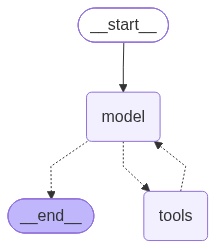

In [26]:
agent

In [18]:
result = agent.invoke({"messages":[{"role":"user","content":"What is 9*9?"}]})

In [19]:
result

{'messages': [HumanMessage(content='What is 9*9?', additional_kwargs={}, response_metadata={}, id='4a4dbbaf-d760-4b65-91bf-d3987e68c590'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 165, 'total_tokens': 185, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVJp5FVfc3eF1bPN5rS3aBlZvtiMr', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a107d9-c154-72e0-be3c-dc5b40f5e961-0', tool_calls=[{'name': 'multiply', 'args': {'a': 9, 'b': 9}, 'id': 'call_gSshCgjLq1SComVW9NPFrN1g', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output

In [20]:
print(result["messages"][-1].content)

81


In [22]:
from pydantic import BaseModel, Field

In [23]:
class ResearchAnswer(BaseModel):
    answer: str
    confidence: str
    sources_used: list[str]

In [ ]:
structured_agent = create_agent(model=CHAT_MODEL, tools=[search_knowledge_base], response_format=ResearchAnswer)

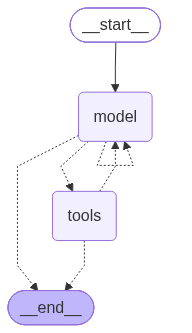

In [25]:
structured_agent

In [27]:
structured_agent.invoke({"messages":[{"role":"user","content":"What is RAG?"}]})

{'messages': [HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='acaa8485-f028-4294-a7c7-7a022174b484'),
  AIMessage(content='', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 187, 'total_tokens': 214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVJrHnA7A5vMaSr9XkmEgQTqCRjPA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a107db-d455-7641-812a-a0244f4a6f41-0', tool_calls=[{'name': 'search_knowledge_base', 'args': {'query': 'What is RAG? retrieval augmented generation definition'}, 'id': 'call_wBgd3KoCcm32uVUPRfrFBdzu', 'type': 't

{'messages': [HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='acaa8485-f028-4294-a7c7-7a022174b484'),
  AIMessage(content='', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 187, 'total_tokens': 214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVJrHnA7A5vMaSr9XkmEgQTqCRjPA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a107db-d455-7641-812a-a0244f4a6f41-0', tool_calls=[{'name': 'search_knowledge_base', 'args': {'query': 'What is RAG? retrieval augmented generation definition'}, 'id': 'call_wBgd3KoCcm32uVUPRfrFBdzu', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 187, 'output_tokens': 27, 'total_tokens': 214, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  ToolMessage(content='Dummy result for query: What is RAG? retrieval augmented generation definition', name='search_knowledge_base', id='06232ea6-7da4-4831-8dea-b330e6405fc0', tool_call_id='call_wBgd3KoCcm32uVUPRfrFBdzu'),
  AIMessage(content='{"answer":"RAG stands for Retrieval-Augmented Generation. It’s an AI pattern where a model first retrieves relevant information from an external source—such as a document database, search index, or knowledge base—and then uses that retrieved context to generate a response.\\n\\nIn practice, RAG helps an AI system:\\n- answer with fresher information than it may have in training\\n- ground responses in specific documents or data\\n- reduce hallucinations by citing relevant context\\n\\nTypical flow:\\n1. User asks a question\\n2. System retrieves related passages/documents\\n3. LLM generates an answer using those passages\\n\\nIt’s commonly used for enterprise search, chatbots over internal docs, and question-answering systems.","confidence":"high","sources_used":["Internal knowledge base search: \\"What is RAG? retrieval augmented generation definition\\""]}', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 181, 'prompt_tokens': 241, 'total_tokens': 422, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVJrH5XEuTCtx6APUYwlLiP4sAKmb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a107db-da3b-7272-a4d6-4dde6a447a31-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 241, 'output_tokens': 181, 'total_tokens': 422, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})],
 'structured_response': ResearchAnswer(answer='RAG stands for Retrieval-Augmented Generation. It’s an AI pattern where a model first retrieves relevant information from an external source—such as a document database, search index, or knowledge base—and then uses that retrieved context to generate a response.\n\nIn practice, RAG helps an AI system:\n- answer with fresher information than it may have in training\n- ground responses in specific documents or data\n- reduce hallucinations by citing relevant context\n\nTypical flow:\n1. User asks a question\n2. System retrieves related passages/documents\n3. LLM generates an answer using those passages\n\nIt’s commonly used for enterprise search, chatbots over internal docs, and question-answering systems.', confidence='high', sources_used=['Internal knowledge base search: "What is RAG? retrieval augmented generation definition"'])}

'structured_response': ResearchAnswer(answer='RAG stands for Retrieval-Augmented Generation. It’s an AI pattern where a model first retrieves relevant information from an external source—such as a document database, search index, or knowledge base—and then uses that retrieved context to generate a response.\n\nIn practice, RAG helps an AI system:\n- answer with fresher information than it may have in training\n- ground responses in specific documents or data\n- reduce hallucinations by citing relevant context\n\nTypical flow:\n1. User asks a question\n2. System retrieves related passages/documents\n3. LLM generates an answer using those passages\n\nIt’s commonly used for enterprise search, chatbots over internal docs, and question-answering systems.', confidence='high', sources_used=['Internal knowledge base search: "What is RAG? retrieval augmented generation definition"'])

In [29]:
from langchain.agents.structured_output import ProviderStrategy, ToolStrategy

In [30]:
provider_strategy_agent = create_agent(model=CHAT_MODEL, tools=[], response_format=ProviderStrategy(ResearchAnswer))

In [32]:
provider_strategy_agent.invoke({"messages":[{"role":"user","content":"What is RAG?"}]})

{'messages': [HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='75544e28-afad-4a3b-8e5c-83158a5de9b8'),
  AIMessage(content='{"answer":"RAG stands for Retrieval-Augmented Generation. It’s an AI approach where a model first retrieves relevant information from an external source, then uses that information to generate a response.\\n\\nIn simple terms:\\n- Retrieval: find relevant documents, passages, or data\\n- Augmented: add that retrieved context to the prompt\\n- Generation: have the model produce the final answer using both its training and the retrieved info\\n\\nWhy it’s useful:\\n- Improves factual accuracy\\n- Lets the model use up-to-date or private data\\n- Reduces hallucinations compared with relying on the model alone\\n\\nCommon uses:\\n- Chatbots over company documents\\n- Search assistants\\n- Q&A over knowledge bases\\n- Customer support tools\\n\\nA basic example: if you ask, “What is our refund policy?” a RAG system searches your poli

{'messages': [HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='75544e28-afad-4a3b-8e5c-83158a5de9b8'),
  AIMessage(content='{"answer":"RAG stands for Retrieval-Augmented Generation. It’s an AI approach where a model first retrieves relevant information from an external source, then uses that information to generate a response.\\n\\nIn simple terms:\\n- Retrieval: find relevant documents, passages, or data\\n- Augmented: add that retrieved context to the prompt\\n- Generation: have the model produce the final answer using both its training and the retrieved info\\n\\nWhy it’s useful:\\n- Improves factual accuracy\\n- Lets the model use up-to-date or private data\\n- Reduces hallucinations compared with relying on the model alone\\n\\nCommon uses:\\n- Chatbots over company documents\\n- Search assistants\\n- Q&A over knowledge bases\\n- Customer support tools\\n\\nA basic example: if you ask, “What is our refund policy?” a RAG system searches your policy docs, pulls the relevant section, and then the model answers based on that text.","confidence":"high","sources_used":[]}', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 209, 'prompt_tokens': 165, 'total_tokens': 374, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVJudjEkzz6BVwBWb1i5wK30DKDqO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a107df-0481-7e40-9300-497390e6a435-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output_tokens': 209, 'total_tokens': 374, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})],
 'structured_response': ResearchAnswer(answer='RAG stands for Retrieval-Augmented Generation. It’s an AI approach where a model first retrieves relevant information from an external source, then uses that information to generate a response.\n\nIn simple terms:\n- Retrieval: find relevant documents, passages, or data\n- Augmented: add that retrieved context to the prompt\n- Generation: have the model produce the final answer using both its training and the retrieved info\n\nWhy it’s useful:\n- Improves factual accuracy\n- Lets the model use up-to-date or private data\n- Reduces hallucinations compared with relying on the model alone\n\nCommon uses:\n- Chatbots over company documents\n- Search assistants\n- Q&A over knowledge bases\n- Customer support tools\n\nA basic example: if you ask, “What is our refund policy?” a RAG system searches your policy docs, pulls the relevant section, and then the model answers based on that text.', confidence='high', sources_used=[])}

In [31]:
tool_strategy_agent = create_agent(model=CHAT_MODEL, tools=[], response_format=ToolStrategy(ResearchAnswer))

In [34]:
tool_strategy_agent.invoke({"messages":[{"role":"user","content":"What is RAG?"}]})

{'messages': [HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='3ed0d8c6-3dc8-440f-841d-d74c93e17f25'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 176, 'prompt_tokens': 132, 'total_tokens': 308, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVJvICccznZMUwXJ8LuRpcG9rh9n2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a107df-a0d0-71a0-ba25-542372c75b1c-0', tool_calls=[{'name': 'ResearchAnswer', 'args': {'answer': 'RAG stands for Retrieval-Augmented Generation. It’s an AI approach where a model first retrieves relevant information from an ex

ResearchAnswer → Defines the exact structured response schema: answer, confidence, and sources_used.

response_format=ResearchAnswer → Lets LangChain automatically choose the best structured-output method for that model.

ProviderStrategy(ResearchAnswer) → Forces LangChain to use the model provider’s native structured output feature.

ToolStrategy(ResearchAnswer) → Forces LangChain to generate structured output using tool/function calling.

provider_strategy_agent → Agent that uses provider-native structured output.

tool_strategy_agent → Agent that uses tool-calling-based structured output.

In [36]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime

In [37]:
# 1. Runtime context structure
@dataclass
class UserContext:
    user_id: str
    role: str

In [38]:
# 2. Tool
@tool
def show_profile(runtime: ToolRuntime[UserContext]) -> str:
    """Show the currently logged-in user's profile."""
    
    user_id = runtime.context.user_id
    role = runtime.context.role

    return f"User ID: {user_id}, Role: {role}"

In [39]:
# 3. Create agent
agent = create_agent(
    model=CHAT_MODEL,
    tools=[show_profile],
    context_schema=UserContext
)

In [ ]:
# 4. Imagine this came from your login/authentication system
logged_in_user = {
    "id": "101",
    "role": "admin"
}

In [41]:
# 5. Invoke agent
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Show my profile"
            }
        ]
    },
    context=UserContext(
        user_id=logged_in_user["id"],
        role=logged_in_user["role"]
    )
)


In [42]:
# 6. Final answer
print(response["messages"][-1].content)

Your profile:
- User ID: 101
- Role: admin


In [43]:
from langchain.agents import create_agent, AgentState
from langchain.agents.middleware import before_model, after_model
from langgraph.runtime import Runtime

@before_model
def log_before(state: AgentState, runtime: Runtime):
    print("Model is about to run")
    return None


@after_model
def log_after(state: AgentState, runtime: Runtime):
    print("Model finished")
    return None

In [44]:

agent = create_agent(
    model=CHAT_MODEL,
    tools=[],
    middleware=[log_before, log_after]
)

In [45]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is RAG?"}
    ]
})

Model is about to run
Model finished


In [47]:
response

{'messages': [HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='9b395d94-05bb-4bef-b7b1-c1760457691c'),
  AIMessage(content='RAG stands for **Retrieval-Augmented Generation**.\n\nIt’s an AI approach where a model:\n1. **Retrieves** relevant information from an external source, like documents, a database, or the web.\n2. **Augments** the model’s prompt with that information.\n3. **Generates** an answer using both the retrieved context and its own language ability.\n\n### Why use RAG?\n- It can answer questions using **fresh or domain-specific information**.\n- It reduces the chance of the model making things up.\n- It lets you use a smaller model with **your own knowledge base**.\n\n### Example\nIf you ask, “What does our company’s vacation policy say?”\n- A RAG system searches the policy documents,\n- pulls the relevant section,\n- then writes a response based on that text.\n\n### In short\nRAG = **search first, then generate**.\n\nIf you want, I can 

In [ ]:
def before_model()
def after_model()
def llm_assistance()

nodes
edges

compile

run()

In [46]:
response

{'messages': [HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='9b395d94-05bb-4bef-b7b1-c1760457691c'),
  AIMessage(content='RAG stands for **Retrieval-Augmented Generation**.\n\nIt’s an AI approach where a model:\n1. **Retrieves** relevant information from an external source, like documents, a database, or the web.\n2. **Augments** the model’s prompt with that information.\n3. **Generates** an answer using both the retrieved context and its own language ability.\n\n### Why use RAG?\n- It can answer questions using **fresh or domain-specific information**.\n- It reduces the chance of the model making things up.\n- It lets you use a smaller model with **your own knowledge base**.\n\n### Example\nIf you ask, “What does our company’s vacation policy say?”\n- A RAG system searches the policy documents,\n- pulls the relevant section,\n- then writes a response based on that text.\n\n### In short\nRAG = **search first, then generate**.\n\nIf you want, I can 

User question
   ↓
before_model()
   ↓
LLM call
   ↓
after_model()
   ↓
Answer

In [48]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest


@dataclass
class UserContext:
    role: str


@dynamic_prompt
def role_prompt(request: ModelRequest) -> str:

    role = request.runtime.context.role

    if role == "beginner":
        return "Explain everything in simple English."

    return "Explain everything technically and in detail."


agent = create_agent(
    model=CHAT_MODEL,
    tools=[],
    middleware=[role_prompt],
    context_schema=UserContext
)

In [49]:
response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "What is RAG?"}
        ]
    },
    context=UserContext(role="beginner")
)

In [50]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest
from langchain.chat_models import init_chat_model

In [51]:
cheap_model = init_chat_model("openai:gpt-5.4-mini")
strong_model = init_chat_model("openai:gpt-5.4")

In [52]:
@wrap_model_call
def choose_model(request: ModelRequest, handler):

    message_count = len(request.state["messages"])

    if message_count > 10:
        selected_model = strong_model
    else:
        selected_model = cheap_model

    request = request.override(
        model=selected_model
    )

    return handler(request)

In [53]:
agent = create_agent(
    model=cheap_model,
    tools=[],
    middleware=[choose_model]
)

In [54]:
response = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Explain RAG in simple English."
        }
    ]
})

print(response["messages"][-1].content)

RAG stands for **Retrieval-Augmented Generation**.

In simple English, it means:

1. **The AI looks up information first**  
   Instead of answering only from what it “remembers,” it searches a document, database, or the web for relevant facts.

2. **Then it writes an answer using that information**  
   The AI combines what it found with its language skills to produce a response.

### Why use RAG?
Because it can:
- give **more accurate** answers
- use **up-to-date** information
- answer questions about **private or company-specific documents**

### Simple example
If you ask:
> “What is our company’s vacation policy?”

A normal AI might guess or give a general answer.

A RAG system would:
- search your company handbook
- find the vacation policy
- then explain it clearly in its answer

### Short version
**RAG = search for useful info + generate an answer from it.**

If you want, I can also explain it with a **real-life analogy** or a **diagram-style example**.


In [55]:
messages = [
    {"role": "user", "content": f"Message {i}"}
    for i in range(11)
]

response = agent.invoke({
    "messages": messages
})

print(response["messages"][-1].content)

Hello! How can I help you today?


before_model
→ Do something BEFORE LLM call

after_model
→ Do something AFTER LLM call

dynamic_prompt
→ Change SYSTEM PROMPT dynamically

wrap_model_call
→ Control / modify the MODEL CALL itself

Model Router
→ Use wrap_model_call to select different models

In [ ]:
from langchain.agents.middleware import (
    SummarizationMiddleware, HumanInTheLoopMiddleware,
    ModelCallLimitMiddleware, ToolCallLimitMiddleware,
    ModelFallbackMiddleware, PIIMiddleware, TodoListMiddleware,
    LLMToolSelectorMiddleware, ToolRetryMiddleware, ModelRetryMiddleware,
    ContextEditingMiddleware, ClearToolUsesEdit,
)


SummarizationMiddleware → Automatically summarizes older conversation history when the context becomes too large.
HumanInTheLoopMiddleware → Pauses risky actions and asks a human to approve, edit, or reject them.
ModelCallLimitMiddleware → Limits how many times the LLM can be called to prevent runaway loops and high cost.
ToolCallLimitMiddleware → Limits how many times tools can be called during a run or thread.
ModelFallbackMiddleware → Uses another model automatically if the primary model fails.
PIIMiddleware → Detects and handles sensitive data such as emails, phone numbers, or credit-card details.
TodoListMiddleware → Lets the agent create and track a task/to-do list for multi-step work.
LLMToolSelectorMiddleware → Uses an LLM to select only the most relevant tools from a large tool set.
ToolRetryMiddleware → Automatically retries a tool when it fails because of a temporary error.
ModelRetryMiddleware → Automatically retries the model call when the LLM/API call fails temporarily.
ContextEditingMiddleware → Removes or edits old context to keep the conversation smaller and cleaner.
ClearToolUsesEdit → Removes older tool-call/tool-result messages from context while keeping recent ones.

!pip install -U deepagents

In [1]:
from deepagents import create_deep_agent

In [2]:
from langchain.tools import tool

In [3]:
@tool
def search_web(query: str) -> str:
    """Search for information."""
    return f"Dummy search result for: {query}"

In [4]:
agent = create_deep_agent(
    model="openai:gpt-5.5",
    tools=[search_web],
    system_prompt="""
    You are a research assistant.
    Research the topic, organize the information,
    and provide a clear final report.
    """
)

In [5]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Research Agentic AI and create a short report."
        }
    ]
})

In [8]:
result

{'messages': [HumanMessage(content='Research Agentic AI and create a short report.', additional_kwargs={}, response_metadata={}, id='2579499b-ee0e-4c04-940e-a85d822b2ed7'),
  AIMessage(content=[{'id': 'rs_090a17112f14b398006aca54cd6c1c87d19f871bdec52f4b64', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqylTOW9-88i8w6-dq7KMWOVdrHalE20puGpMg_6XTqhj_ZJ-FK_Xzr-F7_1Ye8xJ4Tgy_Uzlp2t1tKqsE0IhzWl_3p6EopaIrq0k9FvlRgVG8CuKBgTN9t1vfR3IJ4IL_B2OTMqQ7RjNpPAXW5Hvj2CG3tcIH4h3Ucyy2BpBy__cl1KW3FOssS23qBRS3k6_tO1_RoYKR0veeO7xEL0sPY_-PjnTHe3tt5vQ7bvJu31rcb7enCIDCD7HblAPyn11NKQWecDH3CryEcUE5qV48eWa9N_mQplJDujoOEXpAvtXE2eWI2Oq49MLYk9nzMvKTNaBgc3jLtqzVJfd--F1OkD2w3JAXOuJJSi7Uoupo4LEKH7XjIbip-4HEjoj17uvOYKATLnSPRS8kBTMtkpAOhImnKHXJrZPSy4sdCodDW9f8l0GlBEHMYGiW_UvaH5gO09S2zcgVsbz1oacjWb9IIjjBpeKByFcCjbC9X1vNllmIVP3aEQTOuzE7RS37x3NgHU3pQbsJ_ZxpfEI7tnUJa-Nn1AsD_KDR1vDaH9bt0wjuODUBzSRpYVTYLttkx4oy5yYKfc2rFaEfS1K1IJIPrRR2fM3DxrIACHxWG39GdWr-fZErnUo1rJCyda2e5Z-G1WUHhWk_ZXzrwdvHFvAI8

In [ ]:
{'messages': [HumanMessage(content='Research Agentic AI and create a short report.', additional_kwargs={}, response_metadata={}, id='2579499b-ee0e-4c04-940e-a85d822b2ed7'),
  AIMessage(content=[{'id': 'rs_090a17112f14b398006aca54cd6c1c87d19f871bdec52f4b64', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqylTOW9-88i8w6-dq7KMWOVdrHalE20puGpMg_6XTqhj_ZJ-FK_Xzr-F7_1Ye8xJ4Tgy_Uzlp2t1tKqsE0IhzWl_3p6EopaIrq0k9FvlRgVG8CuKBgTN9t1vfR3IJ4IL_B2OTMqQ7RjNpPAXW5Hvj2CG3tcIH4h3Ucyy2BpBy__cl1KW3FOssS23qBRS3k6_tO1_RoYKR0veeO7xEL0sPY_-PjnTHe3tt5vQ7bvJu31rcb7enCIDCD7HblAPyn11NKQWecDH3CryEcUE5qV48eWa9N_mQplJDujoOEXpAvtXE2eWI2Oq49MLYk9nzMvKTNaBgc3jLtqzVJfd--F1OkD2w3JAXOuJJSi7Uoupo4LEKH7XjIbip-4HEjoj17uvOYKATLnSPRS8kBTMtkpAOhImnKHXJrZPSy4sdCodDW9f8l0GlBEHMYGiW_UvaH5gO09S2zcgVsbz1oacjWb9IIjjBpeKByFcCjbC9X1vNllmIVP3aEQTOuzE7RS37x3NgHU3pQbsJ_ZxpfEI7tnUJa-Nn1AsD_KDR1vDaH9bt0wjuODUBzSRpYVTYLttkx4oy5yYKfc2rFaEfS1K1IJIPrRR2fM3DxrIACHxWG39GdWr-fZErnUo1rJCyda2e5Z-G1WUHhWk_ZXzrwdvHFvAI8e86XpXePBC_95Q0U0OwyD5R4Bm2kKsaHkhb0bipl6ejfe1mNqYsS9MnQ-cx73pAoiXYlfT_ZIfEQj8VHaXyN63RqZa4crt4KF2fiR_7nuq-C3slOKp5ughMD9gn2sKA_xGEVDOTVlDG1ZH7YNSq8Ve6aHDuTtunfxNyHKWSqkHO8K_rEeMp7r3gLyDnuGPO23X-dnXB23u2Oj_OaKDdAmAatZ9OZU3bOSvbtTxc0f9Sm54dAwGNjgEd3JXZzoFMFHOuGTJYR3MNlgTk4JSlVQmi6bygkg00BVMWCKOLzssHs1gbIEmwp0ydhXgr72ZmLPrnMEe0hKPPQdfciMuAfmSpN7fSYgncd3WaBRbziVIl3sp55Rdhmhi8DLQstOxZO70tLkAIySwUNyVgrpe8CGo06AkX8veHPXF4PAZbJ6g58nK4eRKIrSKsv6Ruf_os6R31dw5GBw8372oTqaSMIhAkO3uO9nn7D15LrMUrlvuKSk8TvhNj4HZQ6khSMV7gCx_HQEQRomLnDD1Mem14kwI2HaoR-AT0KPxhPwQ9TWzdSYeSpTL-fzC4UAAgSfs7S3w29L-KTKrSOPQHtp7TFwJ9pI5XLOxOTK8C8axXGGVfZ9bo7WboB9Xif5Lm_yjx2F4cXE2PgG6D4kW08PBXhWjYc35fthuaWBZU8jO-2xPqWTynAygbxnm1OlZqvVPbzTrqYYmw8LoK7ORwGnwBgPYmQ3PEFj5_x0hiytCzWv6wE7E5tUDiXPAKxRScPRKaBv3NC00lY87KT-u83MbgD9hrAgKA7y7flzDcWA6Gbyqk0RUf0tN7QDSuf0ZkaaZyDS-I4QBZKyEUzKfwvAK5oLC1uSNcskjiJgygMcrrIdrqRfAZM97JmBeZVrzJQXjZkx6EeDrB6Rd7NYr5ePfEPCdPtzwAh5AHOh22rLFKVrcI5p5qROy5bY7XLid9Tj_Dcj6zFhcG0GGN-SqXo6rJVD73oIU='}, {'arguments': '{"query":"Agentic AI definition key concepts recent developments risks applications 2024"}', 'call_id': 'call_y12KrFYiFoftf75LUIgfXpPc', 'name': 'search_web', 'type': 'function_call', 'id': 'fc_090a17112f14b398006aca54cdb4d887d1904e45e1aebf4a46', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_090a17112f14b398006aca54cc72bc87d18e24dbce6fd432b2', 'created_at': 1791644876.0, 'metadata': {}, 'model': 'gpt-5.5-2026-04-23', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.5-2026-04-23'}, id='resp_090a17112f14b398006aca54cc72bc87d18e24dbce6fd432b2', tool_calls=[{'name': 'search_web', 'args': {'query': 'Agentic AI definition key concepts recent developments risks applications 2024'}, 'id': 'call_y12KrFYiFoftf75LUIgfXpPc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2023, 'output_tokens': 50, 'total_tokens': 2073, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}, 'output_token_details': {'reasoning': 18}}),
  ToolMessage(content='Dummy search result for: Agentic AI definition key concepts recent developments risks applications 2024', name='search_web', id='9c6f3614-693a-43c2-b253-42f6d1c9b2aa', tool_call_id='call_y12KrFYiFoftf75LUIgfXpPc'),
  AIMessage(content=[{'id': 'rs_090a17112f14b398006aca54cff7a087d1b2f7abd68a43480d', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqylTcw5a60Cg7NGkltno5pmgoxqZaUC3zwtC4bEQMzepjNwu7t8ZtVmPgw-ZOj-tCYrQJ5DjKjIRoEGn85XRWPRwjoupEuBZFK43VgFdRXgtP_WlBsFeuyS6jFT_oap4JEfxNZNUOi6uBrgi6_0j1AV9S-XpgFr7rWqgMqBvPP8182K2eXvAoKvFNGx0g7IjvG1aveNmRfzUn9c_oaan3kXnN0POb8E8Brz2X7Hml0JQyYoJzLpp5pejj9_EJ0g1H2S4AZTs_4UCHVazKQrsDcmdmL-8pE-Uvb6jgGR6sK0Rnoc1pyq9t4cR1iCGC48HfTqpoMIESB1CVaLNH85Vt7u6pQeDxVu-JhDyQ8QSMsNVb2BERaq__e52SSZN97E2XoypmaeWTLO2Kg_7RaAGCtxRjTcnmvQaneRK9lKMFAtwNwCRBfrf7R0HAawCVVJLLo_9idGI0frzgFW4tazcz4mSbf_MNt4LCFyyfXbPXvyQAn3NwfeMb3jOoy6afKcw_EvGELP06oyQFnfZ_4InJKBgECdTwRdKWtRFhGTPwYaueIjY65ihppGNo6A2zszy_ZzRIbC4ocON8oHJRhYjdqG2FtkCceWFmi61aqaSasXXh-BIWOm85nKA3tjtxb-WCEooVgpUnp46lAYKTylJHiYZFZ9FL96EzQKP3QsxB6Fibk5ogffw3UG8EyHK23T7sGNiUJIomZQihKHOW5QXqRHmFtfxel5vtAfv-TOJPhUsFvLq3iWtYfg-02pMYSLhNsZ9u8a7gmhpfTT0rh5BulX0TXTrt639uHWkSbOWmIUteQAlqarU84Tlu3Np3hq2Fv3vv3PRa6OkYyR_JLW6t4aq7I_9CVRGAnXZkzRh_vAr1gCvGuVT3IO-oMDXIeqsVILxqKsh9JvcSFN5mcAQO3IBfO5UvtR2Rw-U1YSqPgr3cHCmi2KaoLpr6UQ_99t-y6sSDcDobRyfgVg1ogq_QfZs1nNMQy_WZUx3mvv5-DRsTm2WzAcEVNBm8GdVlBMy7OhVauyVNiVI9L723tEgbN-OKR9tjElNU9Mw2b06NnHGe4IKKUNDthOplU1a6eviAF4wG8tHuh7xj5tOafLyMINnAjERp9Sb2_mkXUf02QWespWq-LTJX_M-qGnEQTtWnGcq0Tgf9-5Rj5ADXoTuXObuwEg4LVAy5WzBjSpm_Eo_klP30htbP9rE-gtmjDHHVwZfwh1j5nIL4GJWzofpfvhi08YVxM_W4OnV6vhM8sxAy5DT7aFOEVYnhDaYGGbhR4L4S7bsmSH-VLXM7M-m9pP1QIhh0E806k9Buvd8GZjQIQt3LnJbonC9Rp8b1_Lt9sMFCRaIedIubYO6bsUS_AN36CMcfjMeOtx0k7JhjqKugVC3A5aiecIsAPr4947NtvDHxpck7osY2wzxJWzDiepG0YJLiTTa-ZfQOmvKRuScRXPpsJlmcqsN3VKJjQ7Zi5zODtJdtPZJeygsAC2_jlnR--4KIg5PyXxm64qNrQ1T4KvrCeu67UBhHKHh6gkP-tPjsvt6Cr7qqlc9sZC6yXh5bwFs2GQt54DkujL2dH29iO-adjujxDOnN1it2e9uCNpXlT3c0q1fyUUAAvDfQ9ox4icCsO7B9KTSllKQY8Y5K3OCxqX-7dTLAiDwaHx_GKVFPAEdvdbHUPqJqFv0exJYpGxAAxnQvRf6UGVETHc_sXdHDQKYeYyxCfRH8-rS_6Vw20CMlFGJQnNIHaieUMXiBcN0aL5QZaVs7kxVnWdTS1VcjZkEGztk0Tg-R9Gg1nc2JITEpousugABX_w5G0LZ-QA=='}, {'type': 'text', 'text': '## Short Report: Agentic AI\n\n### 1. What is Agentic AI?\n\nAgentic AI refers to artificial intelligence systems that can act with a degree of autonomy to achieve goals. Unlike traditional AI tools that respond to one prompt at a time, agentic AI systems can plan tasks, make decisions, use tools, remember context, and take multiple steps toward completing an objective.\n\nFor example, instead of simply answering “How do I plan a trip?”, an agentic AI system could compare flights, draft an itinerary, book hotels with user approval, update a calendar, and adjust plans if prices change.\n\n---\n\n### 2. Key Characteristics\n\nAgentic AI systems typically include several capabilities:\n\n- **Goal-oriented behavior**: They work toward a defined outcome rather than just producing a single response.\n- **Planning and reasoning**: They break complex tasks into smaller steps.\n- **Tool use**: They can interact with software, APIs, databases, browsers, calendars, code editors, and enterprise systems.\n- **Memory and context**: They may retain relevant information across steps or sessions.\n- **Autonomy**: They can make some decisions without constant human input.\n- **Feedback loops**: They can evaluate results, correct mistakes, and continue iterating.\n\n---\n\n### 3. How Agentic AI Works\n\nA typical agentic AI system combines:\n\n1. **Large language models or multimodal models**  \n   These provide reasoning, language understanding, and decision-making abilities.\n\n2. **Planning module**  \n   The system creates a sequence of actions needed to complete a task.\n\n3. **Tools and integrations**  \n   The agent connects to external systems such as search engines, spreadsheets, CRMs, email, cloud platforms, or code repositories.\n\n4. **Memory system**  \n   Short-term and long-term memory help the agent track progress and personalize actions.\n\n5. **Control and safety layer**  \n   Guardrails, permissions, logging, and human approvals help reduce risk.\n\n---\n\n### 4. Common Applications\n\nAgentic AI is being explored across many industries:\n\n- **Customer service**: Handling multi-step support requests and escalating complex cases.\n- **Software development**: Writing code, debugging, testing, and managing pull requests.\n- **Business operations**: Automating workflows such as invoice processing, scheduling, reporting, and data entry.\n- **Research and analysis**: Gathering information, summarizing documents, and producing reports.\n- **Cybersecurity**: Monitoring threats, investigating alerts, and recommending responses.\n- **Healthcare administration**: Assisting with documentation, scheduling, and claims processing.\n- **Personal productivity**: Managing email, calendars, travel, and task lists.\n\n---\n\n### 5. Benefits\n\nAgentic AI can offer significant advantages:\n\n- **Higher productivity** by automating complex workflows.\n- **Reduced manual effort** for repetitive or administrative tasks.\n- **Faster decision-making** through real-time analysis and action.\n- **Scalability** because agents can operate across many processes at once.\n- **Personalization** by adapting to user preferences and context.\n\n---\n\n### 6. Risks and Challenges\n\nDespite its promise, agentic AI introduces important risks:\n\n- **Loss of control** if systems act beyond intended boundaries.\n- **Errors at scale** when incorrect decisions are automatically repeated.\n- **Security risks** from agents accessing sensitive systems or data.\n- **Prompt injection and manipulation** where malicious content influences agent behavior.\n- **Accountability issues** when it is unclear who is responsible for an agent’s actions.\n- **Bias and unreliable reasoning** inherited from underlying AI models.\n- **Overtrust** by users who may assume autonomous systems are always correct.\n\n---\n\n### 7. Best Practices for Implementation\n\nOrganizations adopting agentic AI should:\n\n- Start with **low-risk, clearly defined workflows**.\n- Use **human-in-the-loop approval** for sensitive actions.\n- Limit agent permissions using the principle of **least privilege**.\n- Maintain strong **logging, monitoring, and audit trails**.\n- Test agents in controlled environments before deployment.\n- Establish clear policies for data privacy, security, and accountability.\n- Regularly evaluate performance, safety, and failure cases.\n\n---\n\n### 8. Outlook\n\nAgentic AI is likely to become a major direction in AI development. As models improve and tool integrations become more reliable, AI agents may increasingly handle complex digital tasks across business and personal environments. However, the technology’s success will depend on balancing autonomy with oversight, reliability, transparency, and security.\n\n---\n\n## Conclusion\n\nAgentic AI represents a shift from AI as a passive assistant to AI as an active problem-solver. It has the potential to transform productivity, software, operations, and service delivery. At the same time, its autonomy creates new technical, ethical, and governance challenges. The most effective uses will likely combine capable AI agents with strong human supervision and well-designed safety controls.', 'annotations': [], 'id': 'msg_090a17112f14b398006aca54d054e887d1b0f28359851b144a', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_090a17112f14b398006aca54cec1b087d18a3d46f8589ea31b', 'created_at': 1791644878.0, 'metadata': {}, 'model': 'gpt-5.5-2026-04-23', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.5-2026-04-23'}, id='resp_090a17112f14b398006aca54cec1b087d18a3d46f8589ea31b', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2102, 'output_tokens': 1026, 'total_tokens': 3128, 'input_token_details': {'cache_creation': 0, 'cache_read': 1536}, 'output_token_details': {'reasoning': 30}})],
 'files': {}}

In [7]:
print(result["messages"][-1].content)

[{'id': 'rs_090a17112f14b398006aca54cff7a087d1b2f7abd68a43480d', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqylTcw5a60Cg7NGkltno5pmgoxqZaUC3zwtC4bEQMzepjNwu7t8ZtVmPgw-ZOj-tCYrQJ5DjKjIRoEGn85XRWPRwjoupEuBZFK43VgFdRXgtP_WlBsFeuyS6jFT_oap4JEfxNZNUOi6uBrgi6_0j1AV9S-XpgFr7rWqgMqBvPP8182K2eXvAoKvFNGx0g7IjvG1aveNmRfzUn9c_oaan3kXnN0POb8E8Brz2X7Hml0JQyYoJzLpp5pejj9_EJ0g1H2S4AZTs_4UCHVazKQrsDcmdmL-8pE-Uvb6jgGR6sK0Rnoc1pyq9t4cR1iCGC48HfTqpoMIESB1CVaLNH85Vt7u6pQeDxVu-JhDyQ8QSMsNVb2BERaq__e52SSZN97E2XoypmaeWTLO2Kg_7RaAGCtxRjTcnmvQaneRK9lKMFAtwNwCRBfrf7R0HAawCVVJLLo_9idGI0frzgFW4tazcz4mSbf_MNt4LCFyyfXbPXvyQAn3NwfeMb3jOoy6afKcw_EvGELP06oyQFnfZ_4InJKBgECdTwRdKWtRFhGTPwYaueIjY65ihppGNo6A2zszy_ZzRIbC4ocON8oHJRhYjdqG2FtkCceWFmi61aqaSasXXh-BIWOm85nKA3tjtxb-WCEooVgpUnp46lAYKTylJHiYZFZ9FL96EzQKP3QsxB6Fibk5ogffw3UG8EyHK23T7sGNiUJIomZQihKHOW5QXqRHmFtfxel5vtAfv-TOJPhUsFvLq3iWtYfg-02pMYSLhNsZ9u8a7gmhpfTT0rh5BulX0TXTrt639uHWkSbOWmIUteQAlqarU84Tlu3Np3hq2Fv3vv3PRa6OkYyR_JLW6t4a

In [ ]:
print(result["messages"][-1].content)

[{'id': 'rs_090a17112f14b398006aca54cff7a087d1b2f7abd68a43480d', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqylTcw5a60Cg7NGkltno5pmgoxqZaUC3zwtC4bEQMzepjNwu7t8ZtVmPgw-ZOj-tCYrQJ5DjKjIRoEGn85XRWPRwjoupEuBZFK43VgFdRXgtP_WlBsFeuyS6jFT_oap4JEfxNZNUOi6uBrgi6_0j1AV9S-XpgFr7rWqgMqBvPP8182K2eXvAoKvFNGx0g7IjvG1aveNmRfzUn9c_oaan3kXnN0POb8E8Brz2X7Hml0JQyYoJzLpp5pejj9_EJ0g1H2S4AZTs_4UCHVazKQrsDcmdmL-8pE-Uvb6jgGR6sK0Rnoc1pyq9t4cR1iCGC48HfTqpoMIESB1CVaLNH85Vt7u6pQeDxVu-JhDyQ8QSMsNVb2BERaq__e52SSZN97E2XoypmaeWTLO2Kg_7RaAGCtxRjTcnmvQaneRK9lKMFAtwNwCRBfrf7R0HAawCVVJLLo_9idGI0frzgFW4tazcz4mSbf_MNt4LCFyyfXbPXvyQAn3NwfeMb3jOoy6afKcw_EvGELP06oyQFnfZ_4InJKBgECdTwRdKWtRFhGTPwYaueIjY65ihppGNo6A2zszy_ZzRIbC4ocON8oHJRhYjdqG2FtkCceWFmi61aqaSasXXh-BIWOm85nKA3tjtxb-WCEooVgpUnp46lAYKTylJHiYZFZ9FL96EzQKP3QsxB6Fibk5ogffw3UG8EyHK23T7sGNiUJIomZQihKHOW5QXqRHmFtfxel5vtAfv-TOJPhUsFvLq3iWtYfg-02pMYSLhNsZ9u8a7gmhpfTT0rh5BulX0TXTrt639uHWkSbOWmIUteQAlqarU84Tlu3Np3hq2Fv3vv3PRa6OkYyR_JLW6t4a

User:
"Research Agentic AI and create a report"
        ↓
Deep Agent
        ↓
Plan the task
        ↓
Search information
        ↓
Maybe use subagents
        ↓
Store intermediate work/files
        ↓
Manage long context
        ↓
Produce final report

| Parameter | Simple meaning | When to use it | Example |
|---|---|---|---|
| `model` | The main LLM used by the agent | Set it explicitly in almost every agent | `model="openai:gpt-5.5"` |
| `tools` | Custom tools or APIs available to the agent | Use when the agent needs access to databases, search, calculators, APIs, RAG, etc. | `tools=[search_docs, get_weather]` |
| `system_prompt` | Main instructions, role, and behavior of the agent | Use when you want to define the agent’s role, rules, or task strategy | `system_prompt="You are a research assistant."` |
| `middleware` | Intercepts and customizes agent execution | Use for retries, logging, PII handling, limits, routing, or custom behavior | `middleware=[PIIMiddleware(...)]` |
| `subagents` | Specialized child agents | Use when research, coding, analysis, or other tasks should be delegated to specialists | `subagents=[researcher]` |
| `skills` | Reusable domain-specific instructions loaded from skill folders | Use for reusable expertise such as SQL, finance, security, or code review | `skills=["/skills/project/"]` |
| `memory` | Loads `AGENTS.md` memory files when the agent starts | Use when the agent should remember persistent instructions, preferences, or knowledge | `memory=["/memory/AGENTS.md"]` |
| `permissions` | Allow, deny, or approval rules for filesystem tools | Use when sensitive files or operations need access control | `permissions=[...]` |
| `backend` | Defines where files are stored and where execution happens | Use when you need local files, state storage, persistent storage, or sandboxed execution | `backend=FilesystemBackend(...)` |
| `interrupt_on` | Pauses before selected tool calls for human approval | Use for risky actions such as delete, send, edit, payment, or deployment | `interrupt_on={"send_email": True}` |
| `response_format` | Defines the exact structured format of the final output | Use when you need JSON, Pydantic, or another structured response | `response_format=Report` |
| `state_schema` | Defines custom internal state that can change while the agent runs | Use when the workflow needs custom changing fields or intermediate state | `state_schema=MyState` |
| `context_schema` | Defines fixed contextual information for one agent run | Use for data such as user ID, role, tenant, permissions, or environment | `context_schema=UserContext` |
| `checkpointer` | Saves thread or agent state between executions | Use when you need conversation memory, pause/resume, HITL, or workflow recovery | `checkpointer=MemorySaver()` |
| `store` | Long-term persistent storage | Use for cross-thread memory, user profiles, preferences, or persistent knowledge | `store=my_store` |
| `debug` | Enables debug information | Use during development and troubleshooting | `debug=True` |
| `name` | Gives the agent a name | Use to identify agents in multi-agent systems, tracing, and logs | `name="research_agent"` |
| `cache` | Reuses cached computations or results | Use when repeated computations or API calls can be safely reused to reduce cost and latency | `cache=my_cache` |

In [ ]:
agent = create_deep_agent(
    model=CHAT_MODEL,

    tools=[
        search_docs,
        search_database
    ],

    system_prompt="You are a senior research analyst.",

    subagents=[
        researcher,
        analyst
    ],

    skills=[
        "/skills/research/",
        "/skills/finance/"
    ],

    memory=[
        "/memory/AGENTS.md"
    ],

    backend=my_backend,

    permissions=my_permissions,

    interrupt_on={
        "send_email": True,
        "delete_file": True
    },

    response_format=ResearchReport,

    context_schema=UserContext,

    checkpointer=checkpointer,

    store=store,

    name="research_agent"
)

In [ ]:
s#eepdee

In [ ]:
# """
# Complete Deep Agents demo.

# Install:
#     pip install -U deepagents langchain langgraph langchain-openai pydantic

# Before running:
#     Set OPENAI_API_KEY in your environment.
# """

# from dataclasses import dataclass
# from pathlib import Path

# from pydantic import BaseModel, Field

# from deepagents import create_deep_agent
# from deepagents.backends.filesystem import FilesystemBackend
# from deepagents.middleware.filesystem import FilesystemPermission

# from langchain.tools import tool
# from langgraph.checkpoint.memory import InMemorySaver
# from langgraph.store.memory import InMemoryStore


# # ============================================================
# # 1. MODEL
# # ============================================================

# CHAT_MODEL = "openai:gpt-5.4-mini"


# # ============================================================
# # 2. DUMMY CUSTOM TOOLS
# # ============================================================

# @tool
# def search_docs(query: str) -> str:
#     """Search internal documents."""
#     return (
#         f"Document result for '{query}': "
#         "LangChain is used for building LLM applications, "
#         "LangGraph provides low-level orchestration, and "
#         "Deep Agents is designed for complex long-running agent work."
#     )


# @tool
# def search_database(query: str) -> str:
#     """Search the internal company database."""
#     return (
#         f"Database result for '{query}': "
#         "Found 3 matching dummy records."
#     )


# @tool
# def send_email(to: str, subject: str, body: str) -> str:
#     """Send an email."""
#     return f"Dummy email sent to {to} with subject '{subject}'."


# @tool
# def delete_file(path: str) -> str:
#     """Delete a file."""
#     return f"Dummy delete completed for: {path}"


# # ============================================================
# # 3. SUBAGENTS
# # ============================================================

# researcher = {
#     "name": "researcher",
#     "description": "Researches technical topics using documents and database search.",
#     "system_prompt": """
# You are a research specialist.
# Research the given topic carefully.
# Use search_docs and search_database when useful.
# Return concise, factual findings to the parent agent.
# """,
#     "tools": [search_docs, search_database],
#     "model": CHAT_MODEL,
# }

# analyst = {
#     "name": "analyst",
#     "description": "Analyzes research findings and produces clear conclusions.",
#     "system_prompt": """
# You are a senior analyst.
# Analyze the information you receive.
# Identify the most important findings, comparisons, and conclusions.
# """,
#     "tools": [search_database],
#     "model": CHAT_MODEL,
# }


# # ============================================================
# # 4. DEMO WORKSPACE
# # ============================================================

# WORKSPACE = (Path.cwd() / "deep_agent_demo").resolve()
# WORKSPACE.mkdir(parents=True, exist_ok=True)


# # ============================================================
# # 5. SKILLS
# # ============================================================

# research_skill_dir = WORKSPACE / "skills" / "research"
# research_skill_dir.mkdir(parents=True, exist_ok=True)

# (research_skill_dir / "SKILL.md").write_text(
#     """---
# name: research
# description: Use this skill when performing technical research.
# ---

# # Research Skill

# 1. Understand the research question.
# 2. Search relevant documents.
# 3. Search the database if useful.
# 4. Compare findings.
# 5. Return evidence-based conclusions.
# """,
#     encoding="utf-8",
# )

# finance_skill_dir = WORKSPACE / "skills" / "finance"
# finance_skill_dir.mkdir(parents=True, exist_ok=True)

# (finance_skill_dir / "SKILL.md").write_text(
#     """---
# name: finance
# description: Use this skill when analyzing financial information.
# ---

# # Finance Skill

# 1. Check revenue.
# 2. Check expenses.
# 3. Identify trends.
# 4. Identify risks.
# 5. Provide a concise conclusion.
# """,
#     encoding="utf-8",
# )

# skills = ["/skills/"]


# # ============================================================
# # 6. MEMORY
# # ============================================================

# memory_dir = WORKSPACE / "memory"
# memory_dir.mkdir(parents=True, exist_ok=True)

# (memory_dir / "AGENTS.md").write_text(
#     """# Agent Memory

# - Prefer concise technical answers.
# - Use examples when explaining concepts.
# - The user is learning LangChain and Deep Agents.
# """,
#     encoding="utf-8",
# )

# memory = ["/memory/AGENTS.md"]


# # ============================================================
# # 7. BACKEND
# # ============================================================

# my_backend = FilesystemBackend(
#     root_dir=WORKSPACE,
#     virtual_mode=True,
# )


# # ============================================================
# # 8. FILESYSTEM PERMISSIONS
# # ============================================================

# my_permissions = [
#     FilesystemPermission(
#         operations=["write"],
#         paths=["/memory/**"],
#         mode="interrupt",
#     )
# ]


# # ============================================================
# # 9. STRUCTURED RESPONSE FORMAT
# # ============================================================

# class ResearchReport(BaseModel):
#     summary: str = Field(description="Short research summary")
#     key_findings: list[str] = Field(description="Important findings")
#     sources: list[str] = Field(description="Sources or tools used")
#     confidence: str = Field(description="Confidence level: low, medium, or high")


# # ============================================================
# # 10. RUN-SCOPED CONTEXT
# # ============================================================

# @dataclass
# class UserContext:
#     user_id: str
#     role: str


# # ============================================================
# # 11. CHECKPOINTER + STORE
# # ============================================================

# checkpointer = InMemorySaver()
# store = InMemoryStore()


# # ============================================================
# # 12. CREATE DEEP AGENT
# # ============================================================

# agent = create_deep_agent(
#     model=CHAT_MODEL,

#     tools=[
#         search_docs,
#         search_database,
#         send_email,
#         delete_file,
#     ],

#     system_prompt="""
# You are a senior research analyst.

# For complex research tasks:
# 1. Understand the task.
# 2. Use specialist subagents when useful.
# 3. Use skills when relevant.
# 4. Search documents or databases when needed.
# 5. Produce an evidence-based final report.

# Do not send emails or delete files unless the user explicitly asks.
# """,

#     subagents=[
#         researcher,
#         analyst,
#     ],

#     skills=skills,
#     memory=memory,

#     backend=my_backend,
#     permissions=my_permissions,

#     interrupt_on={
#         "send_email": True,
#         "delete_file": True,
#     },

#     response_format=ResearchReport,
#     context_schema=UserContext,
#     checkpointer=checkpointer,
#     store=store,
#     name="research_agent",
# )


# # ============================================================
# # 13. INVOKE
# # ============================================================

# def run_demo() -> None:
#     response = agent.invoke(
#         {
#             "messages": [
#                 {
#                     "role": "user",
#                     "content": """
# Research LangChain, LangGraph, and Deep Agents.

# Use the researcher and analyst if useful.

# Give me:
# - a short summary
# - key findings
# - sources used
# - confidence level

# Do not send any email.
# Do not delete any file.
# """,
#                 }
#             ]
#         },

#         context=UserContext(
#             user_id="101",
#             role="admin",
#         ),

#         config={
#             "configurable": {
#                 "thread_id": "research-thread-001",
#             }
#         },
#     )

#     print("\n=== STRUCTURED RESPONSE ===")
#     print(response.get("structured_response"))

#     print("\n=== FINAL MESSAGE ===")
#     if response.get("messages"):
#         print(response["messages"][-1].content)


# if __name__ == "__main__":
#     run_demo()


User
 ↓
UserContext
 ↓
Deep Agent
 │
 ├── System Prompt
 │
 ├── Memory
 │
 ├── Skills
 │      ├── Research
 │      └── Finance
 │
 ├── Tools
 │      ├── search_docs
 │      ├── search_database
 │      ├── send_email
 │      └── delete_file
 │
 ├── Subagents
 │      ├── Researcher
 │      └── Analyst
 │
 ├── FilesystemBackend
 │
 ├── Permissions
 │
 ├── HITL
 │
 ├── Checkpointer
 │
 └── Store
 ↓
ResearchReport

# LangSmith — Observability, Testing and Evals

# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_API_KEY"] = "..."
# os.environ["LANGSMITH_PROJECT"] = "langchain-master-course"

Trace: prompts, model calls, tools, retrieval, nested graphs, latency, tokens and errors.

Evaluate: correctness, groundedness, retrieval quality, tool selection/arguments, trajectory, task success, safety, latency and cost.

Testing docs include unit tests, integration tests and agent evaluations.

difference between the different different agentic framework
3-4 framework will pick

1.mcp-a2a-acp
2. guarideails
3. evaluation
project